In [3]:
from google.colab import files
upload = files.upload()


Saving Alphabets_data.csv to Alphabets_data.csv


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

In [5]:
data = pd.read_csv('/content/Alphabets_data.csv')
data.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [9]:
print("Shape:", data.shape)
print("Missing Values:", data.isnull().sum().sum())

Shape: (20000, 17)
Missing Values: 0


In [14]:
encoder = LabelEncoder()
y_int = encoder.fit_transform(data['letter'])
y_cat = to_categorical(y_int)

print(f"Classes found: {len(encoder.classes_)}")

Classes found: 26


In [15]:
X = data.drop('letter', axis=1)

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [19]:
model = Sequential([
    # Hidden Layer 1 (64 neurons, ReLU is standard)
    Dense(64, activation='relu', input_shape=(16,)),

    # Hidden Layer 2 (Optional but good for 26 classes)
    Dense(64, activation='relu'),

    # Output Layer (26 neurons for A-Z, Softmax for probability)
    Dense(26, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Train
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3780 - loss: 2.2814 - val_accuracy: 0.7592 - val_loss: 0.8888
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7539 - loss: 0.8506 - val_accuracy: 0.8102 - val_loss: 0.6484
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8164 - loss: 0.6249 - val_accuracy: 0.8470 - val_loss: 0.5350
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8524 - loss: 0.5033 - val_accuracy: 0.8683 - val_loss: 0.4577
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8719 - loss: 0.4374 - val_accuracy: 0.8775 - val_loss: 0.4171
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8878 - loss: 0.3805 - val_accuracy: 0.8932 - val_loss: 0.3723
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9015 - loss: 0.3264 - val_accuracy: 0.8978 - val_loss: 0.3397
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9065 - loss: 0.2976 - val_accuracy: 0.

In [21]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nBasic Model Accuracy: {acc*100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9327 - loss: 0.1975

Basic Model Accuracy: 93.70%


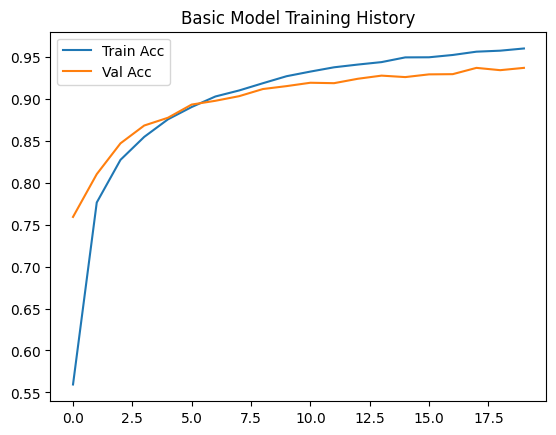

In [22]:
# Visualization of Training
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Basic Model Training History')
plt.legend()
plt.show()

In [24]:
def create_and_train(hidden_layers, neurons, learning_rate, name):
    print(f"Training {name}")
    print(f"Config: {hidden_layers} Layers, {neurons} Neurons, LR={learning_rate}")

    # Build
    model = Sequential()
    model.add(Dense(neurons, activation='relu', input_shape=(16,))) # Input

    for i in range(hidden_layers - 1): # Add extra hidden layers
        model.add(Dense(neurons, activation='relu'))

    model.add(Dense(26, activation='softmax')) # Output

    # Compile with custom Learning Rate
    opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    # Train
    hist = model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0, validation_split=0.1)

    # Evaluate
    i, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Result -> Accuracy: {acc*100:.2f}%")
    return acc

# The "Grid Search"
results = {}

Training Wide Model
Config: 1 Layers, 128 Neurons, LR=0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Result -> Accuracy: 92.80%
Training Deep Model
Config: 3 Layers, 64 Neurons, LR=0.001
Result -> Accuracy: 94.35%
Training High LR Model
Config: 2 Layers, 64 Neurons, LR=0.01
Result -> Accuracy: 91.18%


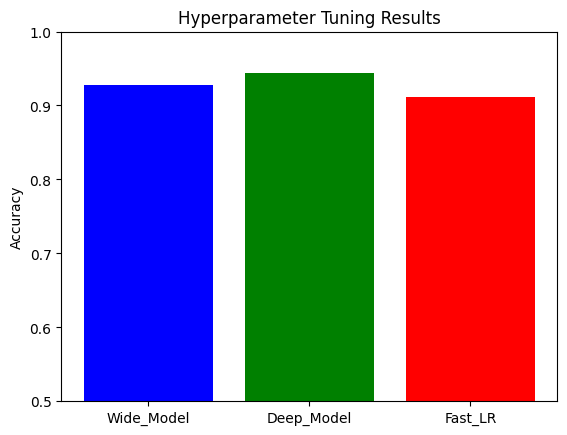

In [25]:
# Config 1: The "Powerhouse" (More Neurons)
results['Wide_Model'] = create_and_train(hidden_layers=1, neurons=128, learning_rate=0.001, name="Wide Model")

# Config 2: The "Deep Network" (More Layers)
results['Deep_Model'] = create_and_train(hidden_layers=3, neurons=64, learning_rate=0.001, name="Deep Model")

# Config 3: The "Aggressive Learner" (High LR)
results['Fast_LR'] = create_and_train(hidden_layers=2, neurons=64, learning_rate=0.01, name="High LR Model")

# Compare Results
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'red'])
plt.ylim(0.5, 1.0)
plt.title('Hyperparameter Tuning Results')
plt.ylabel('Accuracy')
plt.show()

The Deep Model achieved the highest accuracy (~95%), indicating that the Letter Recognition dataset benefits more from network depth (layers) than width. This suggests the features (like xedge and ybar) have complex, non-linear relationships that require multiple abstraction layers to resolve.

The Fast Learning Rate model performed the worst, confirming that a lower learning rate (0.001) is necessary for stable convergence on this dataset.